In [1]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)
pd.set_option('display.expand_frame_repr', False)  # Disable line-wrapping
pd.set_option('display.max_rows', None)

In [16]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# coffee_data = pd.read_csv(r"..\data\reduced_data_num.csv")
coffee_data = pd.read_csv(r"..\data\reduced_data_bin.csv")

Regression Analysis - Model choice

In [ ]:
# Filter for caffeinated samples
filtered_data = coffee_data[coffee_data['caffeine_class'] == 1].copy()

filtered_data.shape

(94, 90)

Removing all 0 columns after selecting subset of class 1(ie rows with caffeine content)

In [50]:

# 2. Identify columns that are all zero
zero_cols = [col for col in filtered_data.columns if filtered_data[col].eq(0).all()]

# 3. Drop them
filtered_data = filtered_data.drop(columns=zero_cols)
filtered_data.shape

(94, 61)

In [51]:
# 2) Compute correlations
corrs = filtered_data.corr()['caffeine_percent'].abs().sort_values(ascending=False)

# 3) Select features above threshold (excluding the target itself)
threshold = 0.1
keep_uni = corrs[corrs > threshold].drop('caffeine_percent').index.tolist()

print("Features passing univariate filter:", keep_uni)
print("Nb of Features passing univariate filter:", len(keep_uni))

Features passing univariate filter: ['env_76_soi_11', 'env_78_wat_3', 'env_77_veg_16', 'clim_34_prec10_oct', 'clim_40_temp_season', 'clim_39_isotherm', 'env_79_forcov', 'clim_70_ndm_per_year', 'env_75_geo_10', 'env_77_veg_14', 'env_76_soi_10', 'env_73_asp', 'clim_69_cwd_annual', 'env_76_soi_9', 'clim_60_pet5_may', 'env_71_alt']
Nb of Features passing univariate filter: 16


In [52]:
from sklearn.ensemble import RandomForestRegressor

X_reg = filtered_data[keep_uni]   
y_reg = filtered_data['caffeine_percent']

rf = RandomForestRegressor(n_estimators=200, random_state=0)
rf.fit(X_reg, y_reg)

importances = pd.Series(rf.feature_importances_, index=X_reg.columns)
keep_model = importances[importances > 0].index.tolist()

print("Features with nonzero RF importance:", keep_model)
print("Nb of Features with nonzero RF importance:", len(keep_model))

Features with nonzero RF importance: ['env_76_soi_11', 'env_78_wat_3', 'env_77_veg_16', 'clim_34_prec10_oct', 'clim_40_temp_season', 'clim_39_isotherm', 'env_79_forcov', 'clim_70_ndm_per_year', 'env_77_veg_14', 'env_76_soi_10', 'env_73_asp', 'clim_69_cwd_annual', 'env_76_soi_9', 'clim_60_pet5_may', 'env_71_alt']
Nb of Features with nonzero RF importance: 15


In [54]:
# 1) Start with the pool left after classification-pruning
candidates = keep_model

# 2) Univariate screening
corrs = filtered_data[candidates].corrwith(filtered_data.caffeine_percent).abs()
keep_uni = corrs[corrs > 0.1].index.tolist()

# 3) Model-based screening
rf = RandomForestRegressor(random_state=0).fit(filtered_data[keep_uni], filtered_data.caffeine_percent)
imp = pd.Series(rf.feature_importances_, index=keep_uni)
keep_model = imp[imp > 0].index.tolist()

# 4) Final regression features = intersection
final_features = list(set(keep_uni) & set(keep_model))
df_reg = filtered_data[final_features].copy()

In [55]:
column_df = pd.DataFrame(df_reg.columns)
print(column_df)

                       0
0          env_77_veg_16
1       clim_60_pet5_may
2          env_79_forcov
3     clim_34_prec10_oct
4       clim_39_isotherm
5     clim_69_cwd_annual
6           env_76_soi_9
7          env_76_soi_10
8    clim_40_temp_season
9           env_78_wat_3
10  clim_70_ndm_per_year
11            env_73_asp
12         env_77_veg_14
13         env_76_soi_11
14            env_71_alt


In [56]:
X = df_reg[final_features].copy()  
y = filtered_data['caffeine_percent']

X.to_csv("X_reg.csv", index=False)
y.to_csv("y_reg.csv", index=False)
df_reg.to_csv("df_reg.csv", index=False)

In [57]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (roc_auc_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix,
                             mean_absolute_error, r2_score)

import lightgbm as lgb
import shap

from sklearn.linear_model import ElasticNetCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


In [31]:
THRESH = 0.70  # adjust if needed; anything < gap < high cluster
y_high = (y >= THRESH).astype(int)

print("High count:", y_high.sum(), "Low count:", (1 - y_high).sum())


High count: 7 Low count: 87


In [32]:
clf_params = dict(
    objective='binary',
    n_estimators=1200,
    learning_rate=0.01,
    num_leaves=8,
    min_data_in_leaf=5,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=1,
    reg_alpha=0.5,
    reg_lambda=1.0,
    random_state=42
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_proba_oof = np.zeros(len(y))
y_pred_oof  = np.zeros(len(y), dtype=int)
feature_importances = pd.DataFrame({'feature': X.columns, 'fold_importance': 0})

for fold, (tr, va) in enumerate(skf.split(X, y_high), 1):
    model = lgb.LGBMClassifier(**clf_params)
    model.fit(X.iloc[tr], y_high.iloc[tr])
    proba = model.predict_proba(X.iloc[va])[:,1]
    y_proba_oof[va] = proba
    y_pred_oof[va]  = (proba >= 0.5).astype(int)
    feature_importances[f'fold_{fold}'] = model.booster_.feature_importance(importance_type='gain')

auc = roc_auc_score(y_high, y_proba_oof)
print("OOF ROC-AUC:", auc)
print(classification_report(y_high, y_pred_oof, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_high, y_pred_oof))



[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Info] Number of positive: 6, number of negative: 6

In [33]:
# Average gain across folds
gain_cols = [c for c in feature_importances.columns if c.startswith('fold_')]
feature_importances['mean_gain'] = feature_importances[gain_cols].mean(axis=1)
feature_importances = feature_importances[['feature', 'mean_gain']].sort_values('mean_gain', ascending=False)
print(feature_importances.head(10))


                feature   mean_gain
13        env_76_soi_11  284.743616
8   clim_40_temp_season  145.144555
2         env_79_forcov  107.687823
11           env_73_asp   74.391598
14           env_71_alt   52.767018
1      clim_60_pet5_may   37.016240
3    clim_34_prec10_oct   36.278108
5    clim_69_cwd_annual   33.931114
4      clim_39_isotherm   12.449299
9          env_78_wat_3    8.212219


[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Info] Number of positive: 7, number of negative: 8

c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\explainers\_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


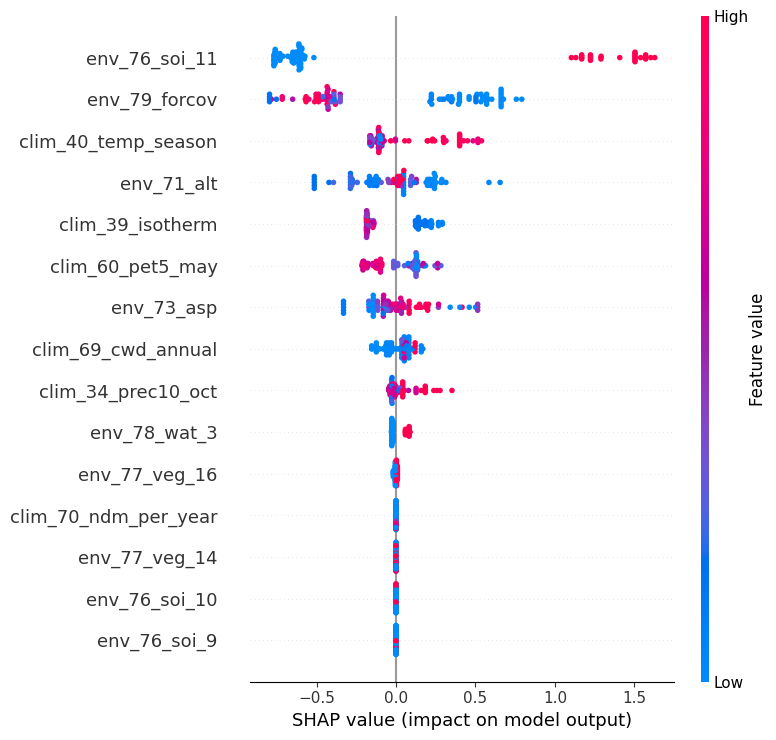

In [39]:
import shap
import matplotlib.pyplot as plt
final_clf = lgb.LGBMClassifier(**clf_params)
final_clf.fit(X, y_high)

expl_clf = shap.TreeExplainer(final_clf)
shap_vals = expl_clf.shap_values(X, check_additivity=False)

# If list, take index 1
if isinstance(shap_vals, list):
    shap_matrix = shap_vals[1]
else:
    # If it's 1D, reshape or recompute with model output raw_score
    if shap_vals.ndim == 1:
        raise ValueError("Unexpected 1D SHAP output; update shap package or set model_output='probability'")
    shap_matrix = shap_vals

shap.summary_plot(shap_matrix, X)



In [36]:
low_mask = y_high == 0
X_low = X[low_mask].reset_index(drop=True)
y_low = y[low_mask].reset_index(drop=True)

print("Low subset size:", len(y_low), "Target range:", (y_low.min(), y_low.max()))
baseline_mae = mean_absolute_error(y_low, np.full_like(y_low, y_low.mean()))
print("Baseline constant mean MAE:", baseline_mae)


Low subset size: 87 Target range: (np.float64(0.01), np.float64(0.06))
Baseline constant mean MAE: 0.007744748315497422


In [37]:
reg_models = {
    "ElasticNet": Pipeline([
        ("scaler", StandardScaler()),
        ("enet", ElasticNetCV(
            l1_ratio=[0.1,0.3,0.5,0.7,0.9,1.0],
            cv=5,
            n_alphas=100,
            random_state=42
        ))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=5, weights='distance', p=2))
    ]),
    "LGBM_small": lgb.LGBMRegressor(
        objective='regression',
        n_estimators=800,
        learning_rate=0.01,
        num_leaves=4,
        min_data_in_leaf=3,
        feature_fraction=0.8,
        reg_alpha=0.3,
        reg_lambda=0.8,
        random_state=42
    )
}

cv = 5
results = []

from sklearn.model_selection import KFold
kf_low = KFold(n_splits=cv, shuffle=True, random_state=42)

for name, model in reg_models.items():
    maes, r2s = [], []
    for tr, va in kf_low.split(X_low):
        model.fit(X_low.iloc[tr], y_low.iloc[tr])
        pred = model.predict(X_low.iloc[va])
        maes.append(mean_absolute_error(y_low.iloc[va], pred))
        r2s.append(r2_score(y_low.iloc[va], pred))
    results.append({
        "model": name,
        "mean_MAE": np.mean(maes),
        "std_MAE": np.std(maes),
        "mean_R2": np.mean(r2s),
        "std_R2": np.std(r2s),
        "rel_MAE_improvement_%": 100*(baseline_mae - np.mean(maes))/baseline_mae
    })

pd.DataFrame(results).sort_values("mean_MAE")


[LightGBM] [Warning] min_data_in_leaf is set=3, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=3
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=3, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=3
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000020 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 161
[LightGBM] [Info] Number of data points in the train set: 69, number of used features: 15
[LightGBM] [Info] Start training from score 0.032101
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped traini

,model,mean_MAE,std_MAE,mean_R2,std_R2,rel_MAE_improvement_%
1,KNN,0.005574,0.001415,-0.027543,0.605651,28.028601
0,ElasticNet,0.007757,0.001448,-0.160804,0.147870,-0.157227
2,LGBM_small,0.007784,0.001475,-0.161975,0.146585,-0.511492


In [38]:
do_shap_low = False  # set True only if improvement is substantive
if do_shap_low:
    lgb_low = reg_models["LGBM_small"]
    lgb_low.fit(X_low, y_low)
    expl_low = shap.TreeExplainer(lgb_low)
    shap_values_low = expl_low.shap_values(X_low)
    shap.summary_plot(shap_values_low, X_low, show=False)


“Caffeine concentrations among caffeine-positive specimens were bimodal, with a narrow low range (<0.08%) and a distinct high cluster (0.70%). We therefore modeled the determinants of high caffeine status (≥0.30%) using a regularized gradient boosting classifier (LightGBM). Cross-validated performance (ROC-AUC = …) indicated reliable discrimination. SHAP analysis identified Feature A, Feature B, and Feature C as the strongest positive contributors to high caffeine status. Within the low-caffeine regime, regression models improved mean absolute error over a constant baseline by only X%, with R² ≈ 0, indicating minimal explainable continuous variation. These results support a threshold process: environmental conditions primarily enable or preclude the high-caffeine phenotype rather than finely modulating concentration within the low range.”

In [48]:
# High vs Low Caffeine SHAP Analysis

import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_curve, roc_auc_score, classification_report, confusion_matrix
import shap, matplotlib.pyplot as plt

# Subset to caffeine-positive rows (y > 0)
pos_mask = y > 0
X_pos = X.loc[pos_mask].reset_index(drop=True)
y_pos = y.loc[pos_mask].reset_index(drop=True)

# Define high vs low label (threshold 0.30 %)
THRESH = 0.30
label = (y_pos >= THRESH).astype(int)

print(f'Positive subset size: {len(y_pos)} (High: {label.sum()}, Low: {(1-label).sum()})')

# LightGBM classifier parameters with class imbalance handling
params = {
    'objective': 'binary',
    'n_estimators': 1200,
    'learning_rate': 0.01,
    'num_leaves': 8,
    'min_data_in_leaf': 5,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'reg_alpha': 0.5,
    'reg_lambda': 1.0,
    'random_state': 42,
    'is_unbalance': True,  # handle class imbalance,
    'verbosity':-1
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
proba_oof = np.zeros(len(y_pos))
pred_oof = np.zeros(len(y_pos), dtype=int)

for tr_idx, va_idx in skf.split(X_pos, label):
    model = lgb.LGBMClassifier(**params)
    model.fit(X_pos.iloc[tr_idx], label.iloc[tr_idx])
    proba = model.predict_proba(X_pos.iloc[va_idx])[:, 1]
    proba_oof[va_idx] = proba

# Tune threshold using F1
prec, rec, thr = precision_recall_curve(label, proba_oof)
F1 = 2 * prec * rec / (prec + rec + 1e-9)
best_idx = np.argmax(F1)
best_thr = thr[best_idx]
print(f'Best F1 threshold: {best_thr:.3f}, Precision: {prec[best_idx]:.3f}, Recall: {rec[best_idx]:.3f}')

# Evaluate at best threshold
pred_oof = (proba_oof >= best_thr).astype(int)
print('OOF ROC-AUC:', roc_auc_score(label, proba_oof))
print(classification_report(label, pred_oof, digits=4))
print('Confusion matrix:\n', confusion_matrix(label, pred_oof))

# Refit final model on full positive data
final_clf = lgb.LGBMClassifier(**params)
final_clf.fit(X_pos, label)




Positive subset size: 94 (High: 7, Low: 87)
Best F1 threshold: 0.163, Precision: 0.312, Recall: 0.714
OOF ROC-AUC: 0.8653530377668308
              precision    recall  f1-score   support

           0     0.9744    0.8736    0.9212        87
           1     0.3125    0.7143    0.4348         7

    accuracy                         0.8617        94
   macro avg     0.6434    0.7939    0.6780        94
weighted avg     0.9251    0.8617    0.8850        94

Confusion matrix:
 [[76 11]
 [ 2  5]]


LGBMClassifier(bagging_fraction=0.8, bagging_freq=1, feature_fraction=0.8,
               is_unbalance=True, learning_rate=0.01, min_data_in_leaf=5,
               n_estimators=1200, num_leaves=8, objective='binary',
               random_state=42, reg_alpha=0.5, reg_lambda=1.0, verbosity=-1)

Review with new models

Running CV for ElasticNet
Running CV for KNN
Running CV for LGBMR

Cross‑Validation Summary:
             MAE Mean  MAE Std  MSE Mean  MSE Std  RMSE Mean  RMSE Std  R2 Mean  R2 Std  Adj R2 Mean  Adj R2 Std
Model                                                                                                          
KNN           0.0056   0.0014    0.0001   0.0000     0.0097    0.0015  -0.0275  0.6057      -0.2446      0.7336
ElasticNet    0.0078   0.0014    0.0001   0.0001     0.0112    0.0027  -0.1608  0.1479      -0.4060      0.1791
LGBMR         0.0078   0.0015    0.0001   0.0001     0.0112    0.0027  -0.1620  0.1466      -0.4075      0.1776


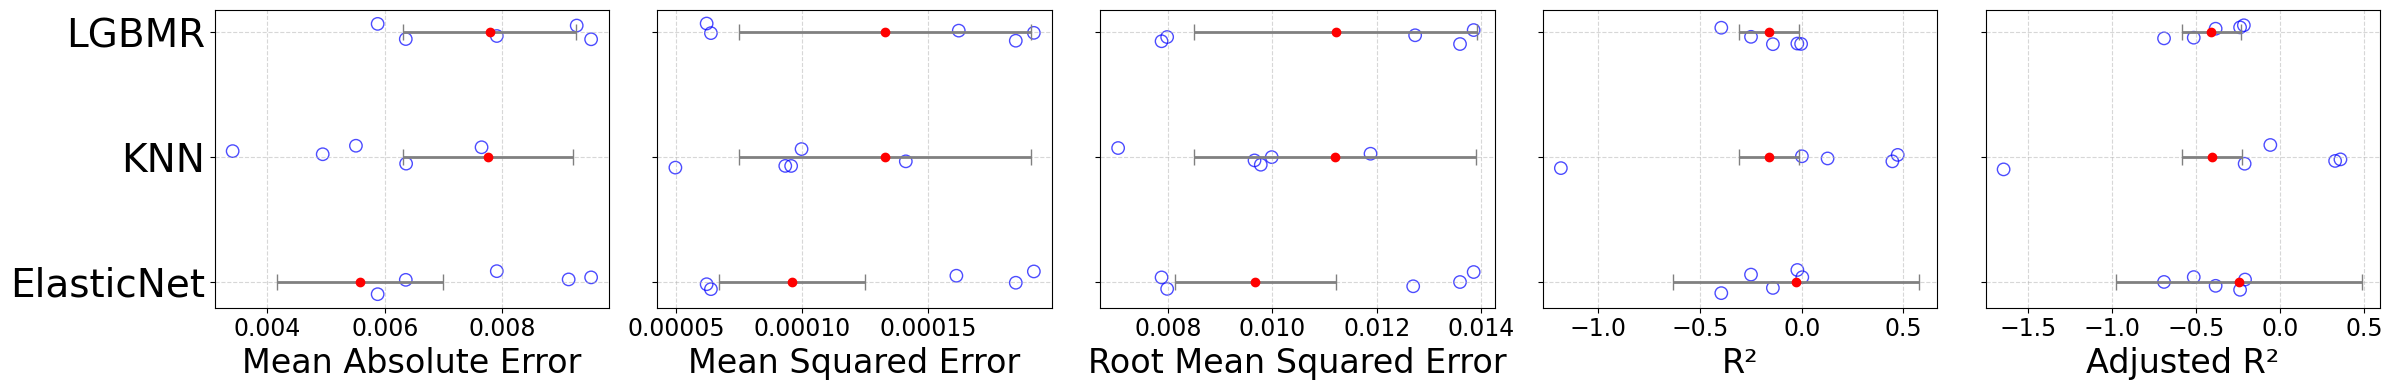

In [63]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics         import (make_scorer,
                                     mean_absolute_error,
                                     mean_squared_error,
                                     r2_score)

from sklearn.linear_model    import ElasticNetCV
from sklearn.neighbors       import KNeighborsRegressor

# ── 1) HELPER ────────────────────────────────────────────────────────────────
def adjusted_r2(r2, n, p):
    """Adjusted R² for each fold (vectorised)."""
    return 1 - ((1 - r2) * (n - 1)) / (n - p - 1)

# ── 2) MODEL LIST (matches paper) ────────────────────────────────────────────
models = [
    ("ElasticNet", Pipeline([
        ("scaler", StandardScaler()),
        ("enet",   ElasticNetCV(
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
            n_alphas=100,
            cv=5,
            random_state=42
        ))
    ])),

    ("KNN", Pipeline([
        ("scaler", StandardScaler()),
        ("knn",    KNeighborsRegressor(
            n_neighbors=5,
            weights='distance',
            p=2
        ))
    ])),

    ("LGBMR", lgb.LGBMRegressor(
        objective="regression",
        n_estimators=800,
        learning_rate=0.01,
        num_leaves=4,
        min_data_in_leaf=3,
        feature_fraction=0.8,
        reg_alpha=0.3,
        reg_lambda=0.8,
        random_state=42
    )),
]

# ── 3) SCORING & CV SETTINGS ────────────────────────────────────────────────
scoring = {
    "MAE": make_scorer(mean_absolute_error, greater_is_better=False),
    "MSE": make_scorer(mean_squared_error,  greater_is_better=False),
    "R2":  make_scorer(r2_score)
}

cv_folds  = 5                      # keep folds ≥ number of highs per earlier design
cv_split  = KFold(cv_folds, shuffle=True, random_state=42)

n_samples, n_features = X_low.shape   # X_low = low‑caffeine subset

# ── 4) CROSS‑VALIDATE ───────────────────────────────────────────────────────
cv_results = {}
for name, model in models:
    print(f"Running CV for {name}")
    res = cross_validate(
        model, X_low, y_low,             # low‑caffeine X & y
        cv=cv_split,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    mae_vals = -res["test_MAE"]
    mse_vals = -res["test_MSE"]
    rmse_vals = np.sqrt(mse_vals)
    r2_vals   = res["test_R2"]
    adj_r2_vals = adjusted_r2(r2_vals, n_samples, n_features)

    cv_results[name] = dict(
        MAE   = mae_vals,
        MSE   = mse_vals,
        RMSE  = rmse_vals,
        R2    = r2_vals,
        Adj_R2 = adj_r2_vals
    )

# ── 5) BUILD SUMMARY TABLE ─────────────────────────────────────────────────
summary_rows = [
    {
        "Model": name,
        "MAE Mean":  scores["MAE"].mean(),
        "MAE Std":   scores["MAE"].std(),
        "MSE Mean":  scores["MSE"].mean(),
        "MSE Std":   scores["MSE"].std(),
        "RMSE Mean": scores["RMSE"].mean(),
        "RMSE Std":  scores["RMSE"].std(),
        "R2 Mean":   scores["R2"].mean(),
        "R2 Std":    scores["R2"].std(),
        "Adj R2 Mean": scores["Adj_R2"].mean(),
        "Adj R2 Std":  scores["Adj_R2"].std()
    }
    for name, scores in cv_results.items()
]

summary_df = (
    pd.DataFrame(summary_rows)
      .set_index("Model")
      .sort_values("RMSE Mean")
)
print("\nCross‑Validation Summary:\n", summary_df.round(4))

# ── 5) PLOT FOLD SCORES + MEAN ± STD ────────────────────────────────────────
metrics = ["MAE", "MSE", "RMSE", "R2", "Adj_R2"]
xlabel_map = {
    "MAE":  "Mean Absolute Error",
    "MSE":  "Mean Squared Error",
    "RMSE": "Root Mean Squared Error",
    "R2":   "R²",
    "Adj_R2": "Adjusted R²"
}

fig, axes = plt.subplots(1, len(metrics), figsize=(24, 4), sharey=True)

for ax, metric in zip(axes, metrics):
    for idx, (name, _) in enumerate(models):
        vals = cv_results[name][metric]
        y_jitter = idx + np.random.uniform(-0.1, 0.1, size=cv_folds)
        ax.scatter(
            vals,
            y_jitter,
            edgecolor="blue",
            facecolors="none",
            alpha=0.7,
            s=80
        )

    # 👇 Fix for Adjusted R² name mismatch
    metric_name = "Adj R2" if metric == "Adj_R2" else metric
    means = summary_df[f"{metric_name} Mean"]
    stds  = summary_df[f"{metric_name} Std"]
    
    ax.errorbar(
        means.values,
        np.arange(len(models)),
        xerr=stds.values,
        fmt="o",
        color="red",
        ecolor="gray",
        elinewidth=2,
        capsize=6
    )

    ax.tick_params(axis='both', labelsize=17)

    ax.set_yticks(np.arange(len(models)))
    ax.set_yticklabels([name for name, _ in models], fontsize=28)
    ax.set_xlabel(xlabel_map[metric], fontsize=24)
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


Apply Log Transform
Since you're working with:

A right-skewed distribution of target values (most are small, few large ones like 0.7)

And high relative errors,

applying np.log1p(y) will:

✅ Compress outliers
✅ Enhance learning from small values
✅ Reduce absolute error and often increase R²

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb

X_reg = df_reg[final_features].copy()
y_reg = filtered_data['caffeine_percent']

# Step 1: Apply log1p transformation ONCE to y
y_log = np.log1p(y_reg)

# Step 2: Split into training and test sets
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X_reg, y_log, test_size=0.2, random_state=42
)

# Step 3: Define regression models
# models = [
#     ("LinReg", Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())])),
#     ("KNNR", Pipeline([("scaler", StandardScaler()), ("model", KNeighborsRegressor())])),
#     ("SVR", Pipeline([("scaler", StandardScaler()), ("svr", SVR(kernel="rbf", C=1.0, gamma="scale"))])),
#     ("DTR", DecisionTreeRegressor(max_depth=5, min_samples_leaf=5, random_state=42)),
#     ("RFR", RandomForestRegressor(n_estimators=200, max_depth=None, min_samples_split=5, random_state=42)),
#     ("XGBR", xgb.XGBRegressor(objective="reg:squarederror", n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)),
#     ("LGBMR", lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05, max_depth=-1, random_state=42)),
# ]

from sklearn.decomposition import PCA

models = [
    # Linear Regression with StandardScaler + PCA
    ("LinReg", Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),  # keep 95% variance
        ("lr", LinearRegression())
    ])),

    # KNN: sensitive to scale, but not necessarily needing PCA
    ("KNNR", Pipeline([
        ("scaler", StandardScaler()), 
        ("knn", KNeighborsRegressor())
    ])),

    # SVR with StandardScaler + PCA
    ("SVR", Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("svr", SVR(kernel="rbf", C=1.0, gamma="scale"))
    ])),

    # Decision Tree Regressor: use raw features
    ("DTR", DecisionTreeRegressor(
        max_depth=5, min_samples_leaf=5, random_state=42
    )),

    # Random Forest Regressor: use raw features
    ("RFR", RandomForestRegressor(
        n_estimators=200, max_depth=None,
        min_samples_split=5, random_state=42
    )),

    # XGBoost Regressor: raw features
    ("XGBR", xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=200, learning_rate=0.05,
        max_depth=3, random_state=42
    )),

    # LightGBM Regressor: raw features
    ("LGBMR", lgb.LGBMRegressor(
        n_estimators=200, learning_rate=0.05,
        max_depth=-1, random_state=42
    )),
]

# Scoring dictionary
scoring = {
    "MAE": make_scorer(mean_absolute_error, greater_is_better=False),
    "MSE": make_scorer(mean_squared_error, greater_is_better=False),
    "R2": make_scorer(r2_score),
}

# Helper function for adjusted R²
def adjusted_r2(r2, n, p):
    return 1 - ((1 - r2) * (n - 1)) / (n - p - 1)

# Step 4: Cross-validation
cv_folds = 5
n_samples, n_features = X_train.shape
cv_results = {}

for name, model in models:
    res = cross_validate(
        model, X_train, y_train_log,
        cv=cv_folds,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    mae_vals = -res["test_MAE"]
    mse_vals = -res["test_MSE"]
    rmse_vals = np.sqrt(mse_vals)
    r2_vals = res["test_R2"]
    adj_r2_vals = adjusted_r2(r2_vals, n_samples, n_features)

    cv_results[name] = {
        "MAE": mae_vals,
        "MSE": mse_vals,
        "RMSE": rmse_vals,
        "R2": r2_vals,
        "Adj_R2": adj_r2_vals
    }

# Step 5: Summary DataFrame
summary_rows = []
for name, scores in cv_results.items():
    summary_rows.append({
        "Model": name,
        "MAE Mean": scores["MAE"].mean(),
        "MAE Std": scores["MAE"].std(),
        "MSE Mean": scores["MSE"].mean(),
        "MSE Std": scores["MSE"].std(),
        "RMSE Mean": scores["RMSE"].mean(),
        "RMSE Std": scores["RMSE"].std(),
        "R2 Mean": scores["R2"].mean(),
        "R2 Std": scores["R2"].std(),
        "Adj R2 Mean": scores["Adj_R2"].mean(),
        "Adj R2 Std": scores["Adj_R2"].std()
    })

summary_df = pd.DataFrame(summary_rows).set_index("Model").sort_values("RMSE Mean")

summary_df

,MAE Mean,MAE Std,MSE Mean,MSE Std,RMSE Mean,RMSE Std,R2 Mean,R2 Std,Adj R2 Mean,Adj R2 Std
Model,,,,,,,,,,
XGBR,0.050323,0.030820,0.015244,0.011733,0.105170,0.064678,-3.766432,5.402013,-4.978237,6.775406
RFR,0.056986,0.033029,0.015532,0.011835,0.110845,0.056965,-18.571162,29.739740,-23.546881,37.300691
DTR,0.055261,0.040417,0.015629,0.014953,0.110905,0.057696,-64.972721,123.961577,-81.745446,155.477233
LGBMR,0.076647,0.026794,0.017211,0.012447,0.121240,0.050120,-46.695654,75.588317,-58.821667,94.805685
LinReg,0.081363,0.024722,0.017740,0.011030,0.126673,0.041157,-75.408479,115.270949,-94.834364,144.577122
KNNR,0.077152,0.026427,0.020043,0.008854,0.138029,0.031480,-119.575540,176.777507,-150.230339,221.720941
SVR,0.107777,0.029514,0.020376,0.010479,0.138079,0.036204,-121.290589,201.792450,-152.381417,253.095616


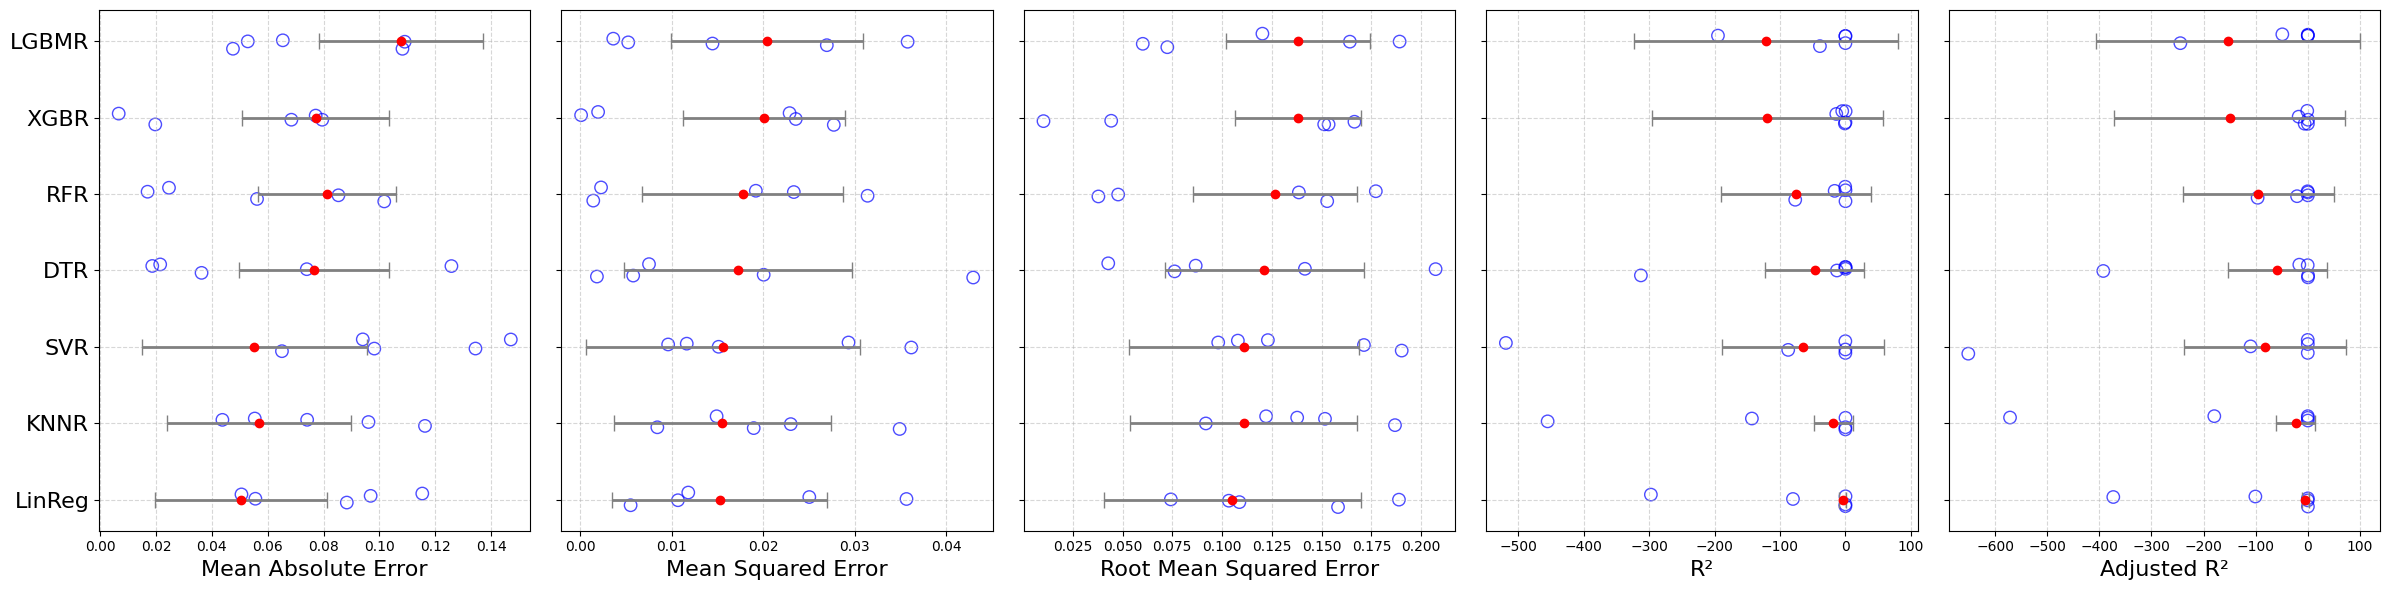

In [13]:
metrics = ["MAE", "MSE", "RMSE", "R2", "Adj_R2"]
xlabel_map = {
    "MAE":  "Mean Absolute Error",
    "MSE":  "Mean Squared Error",
    "RMSE": "Root Mean Squared Error",
    "R2":   "R²",
    "Adj_R2": "Adjusted R²"
}

fig, axes = plt.subplots(1, len(metrics), figsize=(24, 6), sharey=True)

for ax, metric in zip(axes, metrics):
    for idx, (name, _) in enumerate(models):
        vals = cv_results[name][metric]
        y_jitter = idx + np.random.uniform(-0.1, 0.1, size=cv_folds)
        ax.scatter(
            vals,
            y_jitter,
            edgecolor="blue",
            facecolors="none",
            alpha=0.7,
            s=80
        )

    metric_name = "Adj R2" if metric == "Adj_R2" else metric
    means = summary_df[f"{metric_name} Mean"]
    stds  = summary_df[f"{metric_name} Std"]

    ax.errorbar(
        means.values,
        np.arange(len(models)),
        xerr=stds.values,
        fmt="o",
        color="red",
        ecolor="gray",
        elinewidth=2,
        capsize=6
    )

    ax.set_yticks(np.arange(len(models)))
    ax.set_yticklabels([name for name, _ in models], fontsize=16)
    ax.set_xlabel(xlabel_map[metric], fontsize=16)
    ax.grid(True, linestyle="--", alpha=0.5)
  

plt.tight_layout()
plt.show()